In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/kaggle/input/quora-question-pairs/train.csv")


In [3]:
new_df = df.sample(30000,random_state=2) #Adjuted due to machine capacity and time

In [4]:
new_df.head(5)

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [5]:
def preprocess(q):
    q = str(q).lower().strip()

    #replace certain special character with it's string equivalents
    q = q.replace("%", " percent")
    q = q.replace("$", " dollar")
    q = q.replace("₹", " rupees")
    q = q.replace("Rs", " rupees")
    q = q.replace("€", " euro")
    q = q.replace("@", " at")

    #The pattern math appers alot in this dataset
    q = q.replace("math", "")

    #replacing some num with strig equivalents (not perfect can be adjusted for better use)
    q = q.replace("000,000,000", "b")
    q = q.replace("000,000", "m")
    q = q.replace("000", "k")
    q = re.sub(r"([0-9]+)000000000", r"\1b", q)
    q = re.sub(r"([0-9]+)000000", r"\1m", q)
    q = re.sub(r"([0-9]+)000", r"\1k", q)

    #decontracting word
    #https://stackoverflow.com/questions/19790188
    contractions = { 
    "ain't": "am not / are not / is not / has not / have not",
    "aren't": "are not / am not",
    "can't": "cannot",
    "can't've": "cannot have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he had / he would",
    "he'd've": "he would have",
    "he'll": "he shall / he will",
    "he'll've": "he shall have / he will have",
    "he's": "he has / he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how has / how is / how does",
    "I'd": "I had / I would",
    "I'd've": "I would have",
    "I'll": "I shall / I will",
    "I'll've": "I shall have / I will have",
    "I'm": "I am",
    "I've": "I have",
    "isn't": "is not",
    "it'd": "it had / it would",
    "it'd've": "it would have",
    "it'll": "it shall / it will",
    "it'll've": "it shall have / it will have",
    "it's": "it has / it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she had / she would",
    "she'd've": "she would have",
    "she'll": "she shall / she will",
    "she'll've": "she shall have / she will have",
    "she's": "she has / she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as / so is",
    "that'd": "that would / that had",
    "that'd've": "that would have",
    "that's": "that has / that is",
    "there'd": "there had / there would",
    "there'd've": "there would have",
    "there's": "there has / there is",
    "they'd": "they had / they would",
    "they'd've": "they would have",
    "they'll": "they shall / they will",
    "they'll've": "they shall have / they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we had / we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what shall / what will",
    "what'll've": "what shall have / what will have",
    "what're": "what are",
    "what's": "what has / what is",
    "what've": "what have",
    "when's": "when has / when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where has / where is",
    "where've": "where have",
    "who'll": "who shall / who will",
    "who'll've": "who shall have / who will have",
    "who's": "who has / who is",
    "who've": "who have",
    "why's": "why has / why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you had / you would",
    "you'd've": "you would have",
    "you'll": "you shall / you will",
    "you'll've": "you shall have / you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            q_decontracted.append(contractions[word])
        else:
            q_decontracted.append(word)

        
    q = ' '.join(q_decontracted)
    q = q.replace("n't", " not")
    q = q.replace("'ve", " have")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    #Removing HTML tag
    q = BeautifulSoup(q, 'html.parser').get_text()

    #removing Punctuation
    pattern = re.compile('\w')
    q = re.sub(r'[^\w\s]', ' ', q).strip()

    return q

In [6]:
preprocess("<h1>you'll be fired<h1>")

'you will be fired'

In [7]:
new_df["question1"] = new_df["question1"].apply(preprocess)
new_df["question2"] = new_df["question2"].apply(preprocess)

In [8]:
new_df.head(5)

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0


In [9]:
#Feature Engineering
new_df['q1-len'] = new_df['question1'].str.len()
new_df['q2-len'] = new_df['question2'].str.len()

In [10]:
new_df['q1_num_word'] = new_df["question1"].apply(lambda row: len(row.split(" ")))
new_df['q2_num_word'] = new_df["question2"].apply(lambda row: len(row.split(" ")))

In [11]:
new_df.head(5)

,id,qid1,qid2,question1,question2,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9


In [12]:
def common_word(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [13]:
new_df['word_common'] = new_df.apply(common_word, axis = 1)
new_df.head(5)

,id,qid1,qid2,question1,question2,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word,word_common
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,8
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,4
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,1
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3


In [14]:
def total_word(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [15]:
new_df['word_total'] = new_df.apply(total_word, axis = 1)
new_df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word,word_common,word_total
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,8,24
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,4,38


In [16]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'], 2)
new_df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word,word_common,word_total,word_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26,0.46
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,8,24,0.33
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,4,38,0.11


In [17]:
#Advance Feature
from nltk.corpus import stopwords
def fetch_token_feature(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    stopword = stopwords.words('english')

    token_feature = [0.0]*8

    #sentence into token
    q1_token = q1.split()
    q2_token = q2.split()

    if len(q1_token) == 0 or len(q2_token) == 0:
        return token_feature

    #get the non-stopwod in questions
    q1_word = set([word for word in q1_token if word not in stopword])
    q2_word = set([word for word in q2_token if word not in stopword])

    #get the stopword in questions
    q1_stop = set([word for word in q1_token if word in stopword])
    q2_stop = set([word for word in q2_token if word in stopword])

    #get the common non-stopword from question pair
    common_word_count = len(q1_word.intersection(q2_word))

    #get the common stop-word from question pair
    common_stop_count = len(q1_stop.intersection(q2_stop))

    #get the common token from question pair
    common_token_count = len(set(q1_token).intersection(set(q2_token)))

    token_feature[0] = common_word_count/ (min(len(q1_word), len(q2_word)) + SAFE_DIV) # SAFE_DIV sometimes the denominater becomes 0 so we don't need 0
    token_feature[1] = common_word_count/ (max(len(q1_word), len(q2_word)) + SAFE_DIV)
    token_feature[2] = common_stop_count/ (min(len(q1_stop), len(q2_stop)) + SAFE_DIV)
    token_feature[3] = common_stop_count/ (max(len(q1_stop), len(q2_stop)) + SAFE_DIV)
    token_feature[4] = common_token_count/ (min(len(q1_token), len(q2_token)) + SAFE_DIV)
    token_feature[5] = common_token_count/ (max(len(q1_token), len(q2_token)) + SAFE_DIV)

    #last word of both question is same or not
    token_feature[6] = int(q1_token[-1] == q2_token[-1])

    #First word of bot question is same or not
    token_feature[7] = int(q1_token[0] == q2_token[0])

    return token_feature
    

In [18]:
token_feature = new_df.apply(fetch_token_feature, axis=1)

new_df['cwc_min']       = list(map(lambda x: x[0], token_feature))
new_df['cwc_max']       = list(map(lambda x: x[1], token_feature))
new_df['csc_min']       = list(map(lambda x: x[2], token_feature))
new_df['csc_max']       = list(map(lambda x: x[3], token_feature))
new_df['ctc_min']       = list(map(lambda x: x[4], token_feature))
new_df['ctc_max']       = list(map(lambda x: x[5], token_feature))
new_df['last_word_eq']  = list(map(lambda x: x[6], token_feature))
new_df['first_word_eq'] = list(map(lambda x: x[7], token_feature))

In [19]:
new_df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,26,0.46,0.874989,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,24,0.33,0.666644,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,38,0.11,0.000000,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0


In [20]:
!pip install distance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=e25b5841d6ed4683cad5d5ca684a4a6777f45785fe4055236e109e559ef14fd1
  Stored in directory: /root/.cache/pip/wheels/24/a8/58/407063d8e5c1d4dd6594c99d12baa0108570b56a92325587dd
Successfully built distance


In [21]:
import distance

def fetch_length_feature(row):

    q1 = row['question1']
    q2 = row['question2']

    length_feature = [0.0]*3

    #Into token
    q1_token = q1.split()
    q2_token = q2.split()

    if len(q1_token) == 0 or len(q2_token) == 0:
        return length_feature

    #absolute length feature
    length_feature[0] = abs(len(q1_token) - len(q2_token))

    #Average token length of both question
    length_feature[1] = (len(q1_token) + len(q2_token))/2

    strs = list(distance.lcsubstrings(q1, q2))
    length_feature[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

    return length_feature

In [22]:
length_feature = new_df.apply(fetch_length_feature, axis=1)

new_df["abs_len_diff"]         = list(map(lambda x: x[0], length_feature))
new_df["mean_len"]             = list(map(lambda x: x[1], length_feature))
new_df["longest_substr_ratio"] = list(map(lambda x: x[2], length_feature))

In [23]:
new_df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0,0.0,13.0,0.855263
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0,3.0,13.5,0.224490
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0,6.0,23.0,0.047619


In [24]:
!pip install fuzzywuzzy

In [25]:
from fuzzywuzzy import fuzz

def fetch_fuzz_feature(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzz_feature = [0.0]*4

    #fuzz_ratio
    fuzz_feature[0] = fuzz.QRatio(q1, q2)

    #fuzz_partial_ratio
    fuzz_feature[1] = fuzz.partial_ratio(q1, q2)

    #fuzz_sort_ratio
    fuzz_feature[2] = fuzz.token_sort_ratio(q1, q2)

    #fuzz_token_set_ratio
    fuzz_feature[3] = fuzz.token_set_ratio(q1, q2)

    return fuzz_feature

In [26]:
fuzz_feature = new_df.apply(fetch_fuzz_feature, axis=1)

new_df['fuzz_ratio']         = list(map(lambda x: x[0], fuzz_feature))
new_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzz_feature))
new_df['token_sort_ratio']   = list(map(lambda x: x[2], fuzz_feature))
new_df['token_set_ratio']    = list(map(lambda x: x[3], fuzz_feature))

In [27]:
new_df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69,67,65,74
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,0.115384,0.0,0.0,6.0,23.0,0.047619,26,29,34,43


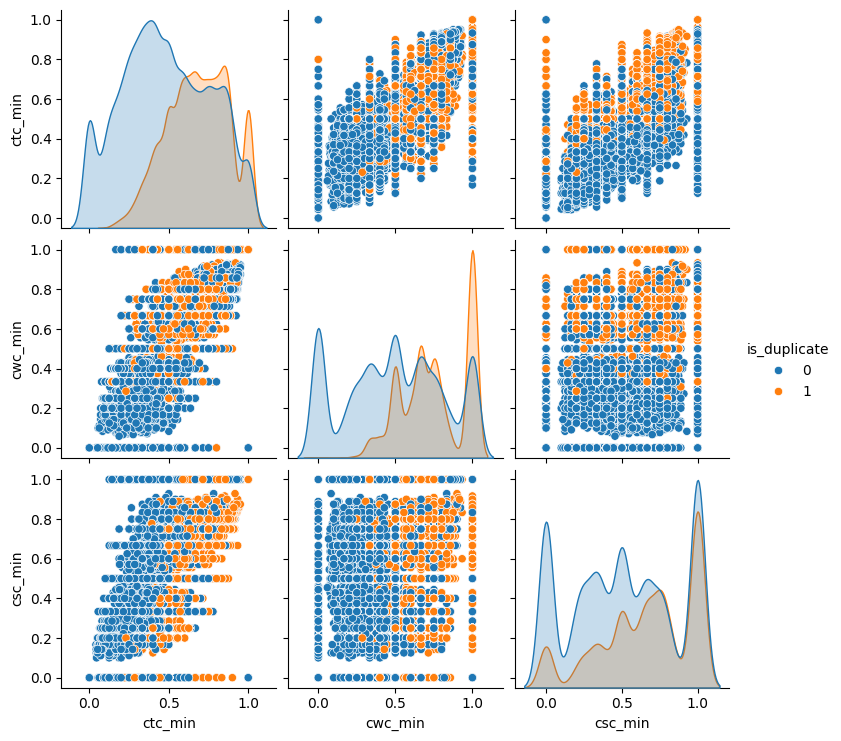

In [28]:
sns.pairplot(new_df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']], hue='is_duplicate')

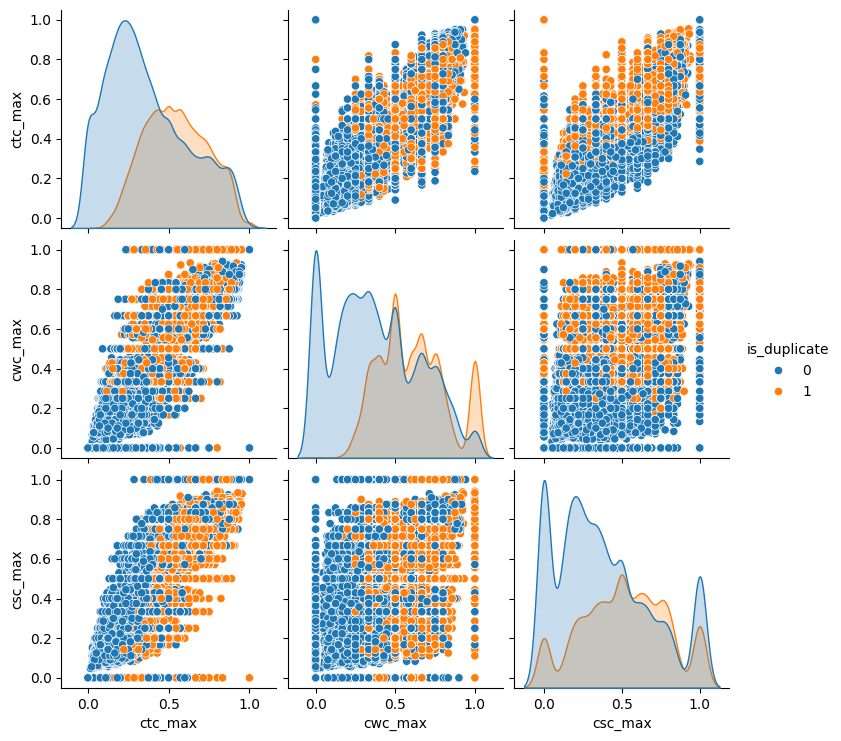

In [29]:
sns.pairplot(new_df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']], hue='is_duplicate')

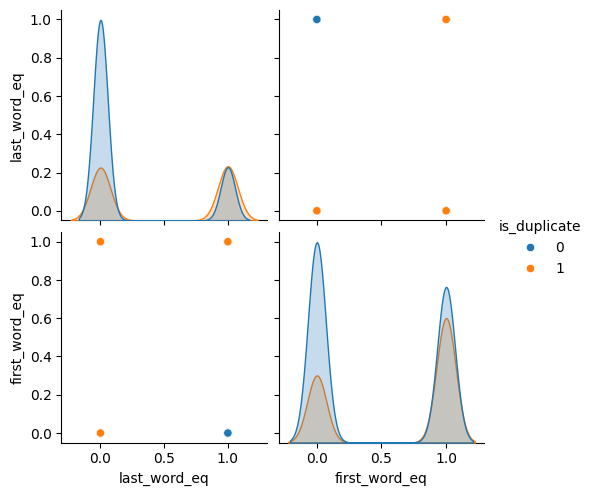

In [30]:
sns.pairplot(new_df[['last_word_eq', 'first_word_eq', 'is_duplicate']], hue='is_duplicate')

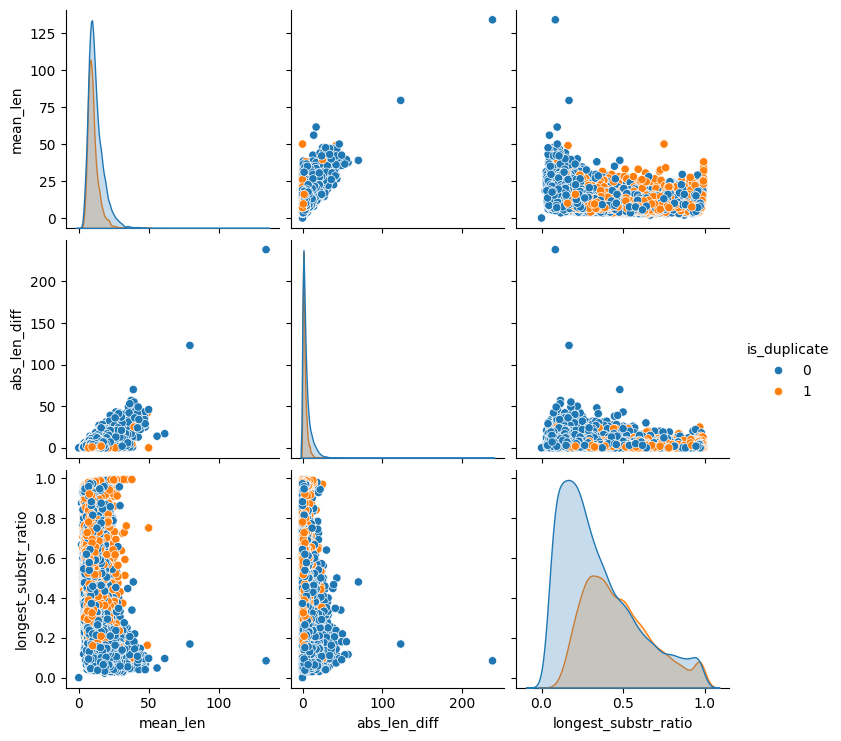

In [31]:
sns.pairplot(new_df[['mean_len', 'abs_len_diff', 'longest_substr_ratio', 'is_duplicate']], hue='is_duplicate')

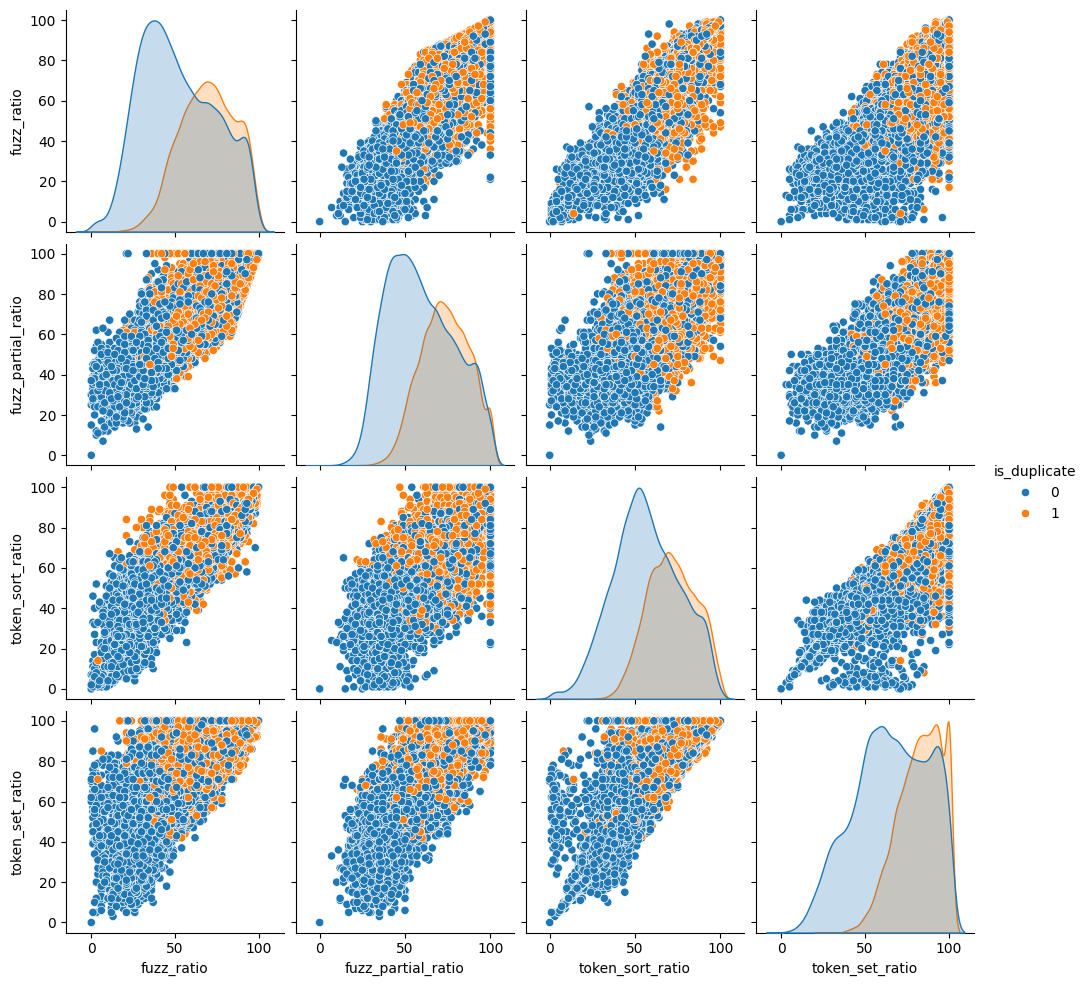

In [32]:
sns.pairplot(new_df[['fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio', 'token_set_ratio', 'is_duplicate']], hue='is_duplicate')

In [33]:
from sklearn.preprocessing import MinMaxScaler

x = MinMaxScaler().fit_transform(new_df[['ctc_min', 'ctc_max', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'last_word_eq', 'first_word_eq', 'mean_len', 'abs_len_diff', 'longest_substr_ratio', 'fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio', 'token_set_ratio']])
y = new_df['is_duplicate'].values

In [34]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,
    init='random', #pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.085s...
[t-SNE] Computed neighbors for 30000 samples in 6.630s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

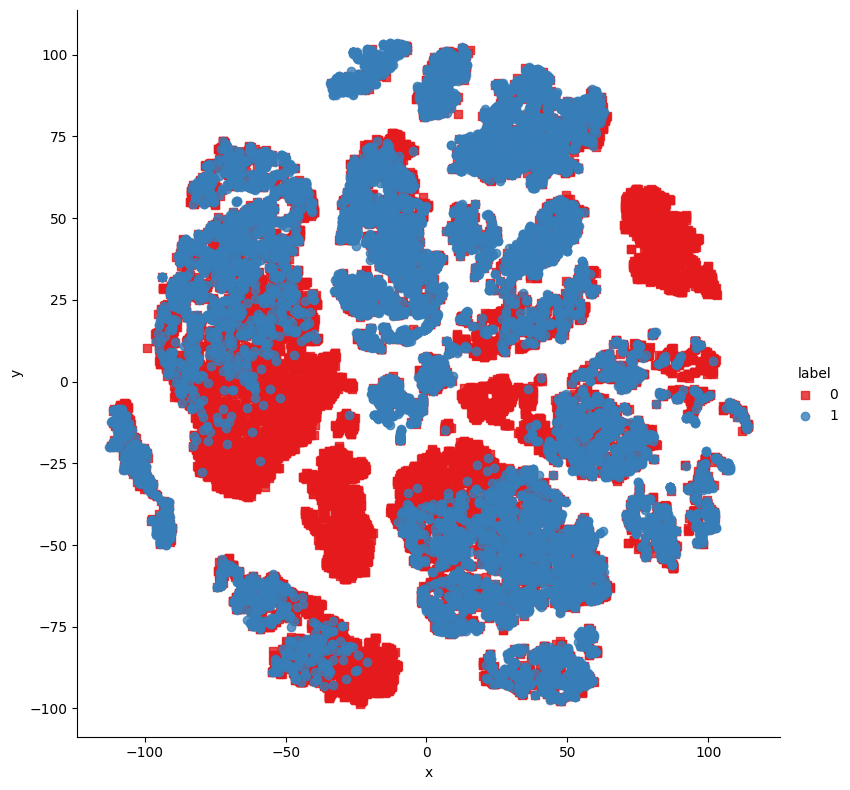

In [35]:
x_df = pd.DataFrame({'x':tsne2d[:,0], 'y':tsne2d[:,1] ,'label':y})

# draw the plot in appropriate place in the grid
sns.lmplot(data=x_df, x='x', y='y', hue='label', fit_reg=False, height=8,palette="Set1",markers=['s','o'])

In [36]:
from sklearn.manifold import TSNE

tsne3d = TSNE(
    n_components=3,
    init='random', #pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.088s...
[t-SNE] Computed neighbors for 30000 samples in 6.568s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

In [37]:
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.io as pio

# Force renderer
pio.renderers.default = 'colab'
subset_size = 1000
trace1 = go.Scatter3d(
    x=tsne3d[:subset_size, 0],
    y=tsne3d[:subset_size, 1],
    z=tsne3d[:subset_size, 2],
    mode='markers',
    marker=dict(size=3, color=y[:subset_size], colorscale='Portland', opacity=0.6)
)

fig = go.Figure(data=[trace1], layout=dict(height=700, width=700, title='3D Embedding (Sampled)'))
fig.show()

In [38]:
ques_df = new_df[['question1', 'question2']]
ques_df.head(5)

,question1,question2
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...
115086,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...
327711,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...
367788,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...
151235,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy


In [39]:
final_df = new_df.drop(columns=['id', 'qid1', 'qid2', 'question1', 'question2'])
print(final_df.shape)
final_df.head(5)

(30000, 23)


,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,0,48,56,13,16,8,24,0.33,0.666644,0.499988,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69,67,65,74
327711,0,104,119,28,21,4,38,0.11,0.000000,0.000000,...,0.115384,0.0,0.0,6.0,23.0,0.047619,26,29,34,43
367788,0,58,145,14,32,1,34,0.03,0.000000,0.000000,...,0.000000,0.0,0.0,17.0,21.5,0.050847,29,41,23,30
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0.333330,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


In [40]:
from sklearn.feature_extraction.text import CountVectorizer

#merge text
question = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(question).toarray(),2)

In [41]:
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)
temp_df  = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [42]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head(5)

(30000, 6023)


,is_duplicate,q1-len,q2-len,q1_num_word,q2_num_word,word_common,word_total,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,0,0,0,0,0,0,0,0,0,0
115086,0,48,56,13,16,8,24,0.33,0.666644,0.499988,...,0,0,0,0,0,0,0,0,0,0
327711,0,104,119,28,21,4,38,0.11,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
367788,0,58,145,14,32,1,34,0.03,0.000000,0.000000,...,0,0,0,1,0,0,0,0,0,0
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0,0,0,0,0,0,0,0,0,0


In [43]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(final_df.iloc[:,1:].values, final_df.iloc[:,0].values, test_size=0.2, random_state=1)

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
accuracy_score(y_test, y_pred)

0.7848333333333334

In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_pred1 = xgb.predict(x_test)
accuracy_score(y_test, y_pred1)


0.7948333333333333

In [46]:
from sklearn.metrics import confusion_matrix

In [47]:
#for random forest model
confusion_matrix(y_test, y_pred)

array([[3273,  539],
       [ 752, 1436]])

In [48]:
#for XGBClassifier
confusion_matrix(y_test, y_pred1)

array([[3244,  568],
       [ 663, 1525]])

In [49]:
def test_common_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return len(w1 & w2)

In [50]:
def test_total_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return (len(w1) + len(w2))

In [51]:
def test_fetch_token_features(q1,q2):
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [52]:
def test_fetch_length_features(q1,q2):
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [53]:
def test_fetch_fuzzy_features(q1,q2):
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [54]:
def query_point_creator(q1,q2):
    
    input_query = []
    
    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)
    
    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))
    
    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))
    
    input_query.append(test_common_words(q1,q2))
    input_query.append(test_total_words(q1,q2))
    input_query.append(round(test_common_words(q1,q2)/test_total_words(q1,q2),2))
    
    # fetch token features
    token_features = test_fetch_token_features(q1,q2)
    input_query.extend(token_features)
    
    # fetch length based features
    length_features = test_fetch_length_features(q1,q2)
    input_query.extend(length_features)
    
    # fetch fuzzy features
    fuzzy_features = test_fetch_fuzzy_features(q1,q2)
    input_query.extend(fuzzy_features)
    
    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()
    
    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()
    
    
    
    return np.hstack((np.array(input_query).reshape(1,22),q1_bow,q2_bow))

In [55]:
q1 = 'Where is the capital of India?'
q2 = 'What is the current capital of Pakistan?'
q3 = 'Which city serves as the capital of India?'
q4 = 'What is the business capital of India?'

In [56]:
rf.predict(query_point_creator(q1,q4))

array([1])

In [57]:
cv

CountVectorizer(max_features=3000)

In [58]:
import pickle

pickle.dump(rf,open('model.pkl','wb'))
pickle.dump(cv,open('cv.pkl','wb'))

In [59]:
!ls

cv.pkl	model.pkl
